# Task

Simulate data from the CAR T-Cell model from Liu et al Paper

In [4]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import random
import matplotlib.pyplot as plt

## Defining the Equations

In [5]:
def car_t_cell_model(y, t, params):
    nP, nTA, nTN, nN = y
    rP, nC, e, KP, rTA, Kr, KA, lTA, kA, lTN, rN, km, kb, KN = params

    dnP_dt = rP * (1 - nP / nC) * nP - (e * nP / (nP + KP)) * nTA
    dnTA_dt = rTA * (nP / (nP + Kr)) * nTA + kA * (nP / (nP + KA)) * nTN - lTA * nTA
    dnTN_dt = -kA * (nP / (nP + KA)) * nTN - lTN * nTN
    dnN_dt = rN * (1 - nN / nC) * nN + km * nP - e / kb * nN / (nN + KN) * nTA

    return [dnP_dt, dnTA_dt, dnTN_dt, dnN_dt]


def sample_parameters(pop_params, pop_stds, n_samples, seed=42):
    """
    Generate n samples of parameters based on population parameters and standard deviations.

    Args:
    - pop_params (list): List of mean values for the parameters.
    - pop_stds (list): List of standard deviations for the parameters.
    - n_samples (int): Number of samples to generate.

    Returns:
    - List of n sampled parameter sets (lists).
    """
    random.seed(seed)
    sampled_params = []
    for _ in range(n_samples):
        sample = [random.gauss(mean, std) for mean, std in zip(pop_params, pop_stds)]
        sampled_params.append(sample)
    return sampled_params


def simulate_dynamics(sampled_params, initial_conditions, time):
    """
    Simulate the CAR T-cell and tumor dynamics for multiple parameter sets.

    Args:
    - sampled_params (list): List of sampled parameter sets.
    - initial_conditions (list): Initial conditions for the ODEs [nP0, nTA0, nTN0].
    - time (array): Time points for simulation.

    Returns:
    - List of results, where each entry contains [time, nP, nTA, nTN] for one simulation.
    """
    results = []
    for params in sampled_params:
        # Solve the ODEs for the current parameter set
        solution = odeint(car_t_cell_model, initial_conditions, time, args=(params,))
        nP, nTA, nTN, nN = solution.T  # Transpose to extract individual dynamics
        results.append({"time": time, "nP": nP, "nTA": nTA, "nTN": nTN, "nN": nN})
    return results

# Define population parameters (means) and standard deviations
pop_params = [
    0.069,      # rP: CD19+ growth rate
    2200.24,    # nC: Tumor carrying capacity
    22.72,      # e: Killing rate of activated CAR T-cells
    50.0,       # KP: Saturation constant for CAR T-cell killing
    1.62,       # rTA: Growth rate of activated CAR T-cells
    100.0,      # Kr: Saturation constant for CAR T-cell growth
    50.0,       # KA: Saturation constant for CAR T-cell activation
    0.12,       # lTA: Apoptosis rate of activated CAR T-cells
    0.5,        # kA: Activation rate of non-activated CAR T-cells
    0.1,        # lTN: Apoptosis rate of non-activated CAR T-cells
    0.1,        # rN: CD19- growth rate
    1.5e-7,     # km: Mutation factor
    7.9,        # kb: Bystandard killing scaling factor
    16956.03,   # KN: Saturation rate for  of CD19 B-ALL cell to killing efficacy
]
pop_stds = [
    0.005,   # rP
    200.0,   # nC
    1.5,     # e
    5.0,     # KP
    0.1,     # rTA
    10.0,    # Kr
    5.0,     # KA
    0.01,    # lTA
    0.05,    # kA
    0.01,    # lTN
    0.005,   # rN
    1.5e-8,  # km
    0.8,     # kb
    1700.0,  # kN
]


### Simulating and Plotting

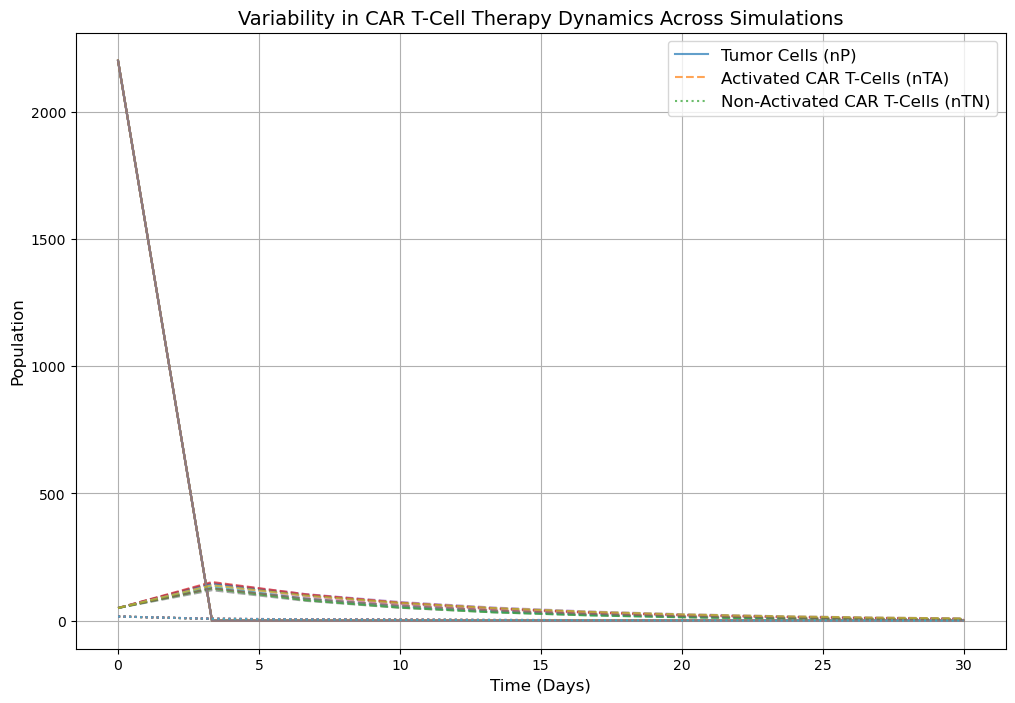

In [6]:
n_samples = 10


sampled_params = sample_parameters(pop_params, pop_stds, n_samples)


initial_conditions = [2200.24, 50.0, 16.5, 19.89]  # [nP0, nTA0, nTN0, nN0]


time = np.linspace(0, 30, 10)


simulation_results = simulate_dynamics(sampled_params, initial_conditions, time)


plt.figure(figsize=(12, 8))
for result in simulation_results:
    plt.plot(result["time"], result["nP"], alpha=0.7, label="Tumor Cells (nP)" if "Tumor Cells (nP)" not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.plot(result["time"], result["nTA"], alpha=0.7, linestyle="--", label="Activated CAR T-Cells (nTA)" if "Activated CAR T-Cells (nTA)" not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.plot(result["time"], result["nTN"], alpha=0.7, linestyle=":", label="Non-Activated CAR T-Cells (nTN)" if "Non-Activated CAR T-Cells (nTN)" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("Variability in CAR T-Cell Therapy Dynamics Across Simulations", fontsize=14)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.legend(fontsize=12, loc="upper right")
plt.grid()
plt.show()


In [7]:
results2 = {
    "time": [],
    "id": [],
    "observation": [],
    "observation_id": [],
    "observation_type": [],
}

observation_types = ["nP", "nTA", "nTN", "nN"]

for i, result in enumerate(simulation_results):
    for j, t in enumerate(result["time"]):
        for obs_id, obs_type in enumerate(observation_types):
            obs = result[obs_type][j]
            results2["time"].append(t)
            results2["id"].append(i)
            results2["observation"].append(obs)
            results2["observation_id"].append(obs_id)
            results2["observation_type"].append(obs_type)
        

In [8]:
pd.DataFrame(results2).to_csv("cart_data_no_noise.csv", index=False)

In [9]:
def aggregate_simulation_data(simulation_results):
    time_points = simulation_results[0]["time"]
    nP_values = []
    nTA_values = []
    nTN_values = []
    for t_idx in range(len(time_points)):
        nP_values.append([result["nP"][t_idx] for result in simulation_results])
        nTA_values.append([result["nTA"][t_idx] for result in simulation_results])
        nTN_values.append([result["nTN"][t_idx] for result in simulation_results])
    stats = {
        "Time (Days)": time_points,
        "nP_Mean": [np.mean(values) for values in nP_values],
        "nP_Std": [np.std(values) for values in nP_values],
        "nTA_Mean": [np.mean(values) for values in nTA_values],
        "nTA_Std": [np.std(values) for values in nTA_values],
        "nTN_Mean": [np.mean(values) for values in nTN_values],
        "nTN_Std": [np.std(values) for values in nTN_values],
    }
    return pd.DataFrame(stats)

def refine_simulation_with_variability_and_scenarios(sampled_params, initial_conditions, time, scenario="immune_escape"):
    refined_results = []
    for params in sampled_params:
        if scenario == "immune_escape":
            params[0] *= 1.1
            params[2] *= 0.8
        elif scenario == "treatment_failure":
            params[7] *= 1.5
            params[8] *= 0.5
            params[9] *= 1.5
        varied_initial_conditions = [
            initial_conditions[0] * random.uniform(0.9, 1.1),
            initial_conditions[1] * random.uniform(0.9, 1.1),
            initial_conditions[2] * random.uniform(0.9, 1.1)
        ]
        solution = odeint(car_t_cell_model, varied_initial_conditions, time, args=(params,))
        nP, nTA, nTN = solution.T
        refined_results.append({"time": time, "nP": nP, "nTA": nTA, "nTN": nTN})
    return refined_results

In [10]:
def aggregate_simulation_data(simulation_results):
    time_points = simulation_results[0]["time"]
    nP_values = []
    nTA_values = []
    nTN_values = []
    for t_idx in range(len(time_points)):
        nP_values.append([result["nP"][t_idx] for result in simulation_results])
        nTA_values.append([result["nTA"][t_idx] for result in simulation_results])
        nTN_values.append([result["nTN"][t_idx] for result in simulation_results])
    stats = {
        "Time (Days)": time_points,
        "nP_Mean": [np.mean(values) for values in nP_values],
        "nP_Std": [np.std(values) for values in nP_values],
        "nTA_Mean": [np.mean(values) for values in nTA_values],
        "nTA_Std": [np.std(values) for values in nTA_values],
        "nTN_Mean": [np.mean(values) for values in nTN_values],
        "nTN_Std": [np.std(values) for values in nTN_values],
    }
    return pd.DataFrame(stats)

def refine_simulation_with_variability_and_scenarios(sampled_params, initial_conditions, time, scenario="immune_escape"):
    refined_results = []
    for params in sampled_params:
        if scenario == "immune_escape":
            params[0] *= 1.1
            params[2] *= 0.8
        elif scenario == "treatment_failure":
            params[7] *= 1.5
            params[8] *= 0.5
            params[9] *= 1.5
        varied_initial_conditions = [
            initial_conditions[0] * random.uniform(0.9, 1.1),
            initial_conditions[1] * random.uniform(0.9, 1.1),
            initial_conditions[2] * random.uniform(0.9, 1.1)
        ]
        solution = odeint(car_t_cell_model, varied_initial_conditions, time, args=(params,))
        nP, nTA, nTN = solution.T
        refined_results.append({"time": time, "nP": nP, "nTA": nTA, "nTN": nTN})
    return refined_results

In [11]:

pop_params = [0.069, 2200.24, 22.72, 50.0, 1.62, 100.0, 50.0, 0.12, 0.5, 0.1]
pop_stds = [0.005, 200.0, 1.5, 5.0, 0.1, 10.0, 5.0, 0.01, 0.05, 0.01]
n_samples = 10
sampled_params = sample_parameters(pop_params, pop_stds, n_samples)
initial_conditions = [2200.24, 50.0, 16.5]
time = np.linspace(0, 30, 100)
refined_results = refine_simulation_with_variability_and_scenarios(sampled_params, initial_conditions, time, scenario="immune_escape")
aggregated_refined_data = aggregate_simulation_data(refined_results)
plt.figure(figsize=(12, 8))
for result in refined_results:
    plt.plot(result["time"], result["nP"], alpha=0.7, label="Tumor Cells (nP)" if "Tumor Cells (nP)" not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.plot(result["time"], result["nTA"], alpha=0.7, linestyle="--", label="Activated CAR T-Cells (nTA)" if "Activated CAR T-Cells (nTA)" not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.plot(result["time"], result["nTN"], alpha=0.7, linestyle=":", label="Non-Activated CAR T-Cells (nTN)" if "Non-Activated CAR T-Cells (nTN)" not in plt.gca().get_legend_handles_labels()[1] else "")
plt.title("Variability in CAR T-Cell Therapy Dynamics (Immune Escape Scenario)", fontsize=14)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.legend(fontsize=12, loc="upper right")
plt.grid()
plt.show()

ValueError: not enough values to unpack (expected 4, got 3)